In [1]:
!pip install -q pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100

In [3]:
COLS = ['Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA',
        'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr',
        'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed',
        'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
SENSORS = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr',
           'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed',
           'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']

df = pd.read_csv('../Data/train_FD001.txt', sep=' ', header=None)
df = df.iloc[:, :26]
df.columns = COLS

max_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('max_cycle')
df = df.join(max_cycle, on='Unit Number')
df['RUL'] = df['max_cycle'] - df['Time (Cycles)']
df['life_pct'] = df['Time (Cycles)'] / df['max_cycle']

print(f'Rows: {len(df):,}  |  Engines: {df["Unit Number"].nunique()}')
df.head(3)

Rows: 20,631  |  Engines: 100


,Unit Number,Time (Cycles),Altitude,Mach Number,TRA,T2,T24,T30,T50,P2,...,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,max_cycle,RUL,life_pct
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191,0.005208
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190,0.010417
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189,0.015625


# Sensor–RUL correlation by lifecycle segment

Each engine's lifecycle is divided into equal segments based on normalised time (0 = start, 1 = failure).
The heatmap shows how strongly each sensor correlates with RUL within that segment.
A sensor that changes colour across segments is one whose importance shifts over the engine's life.

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


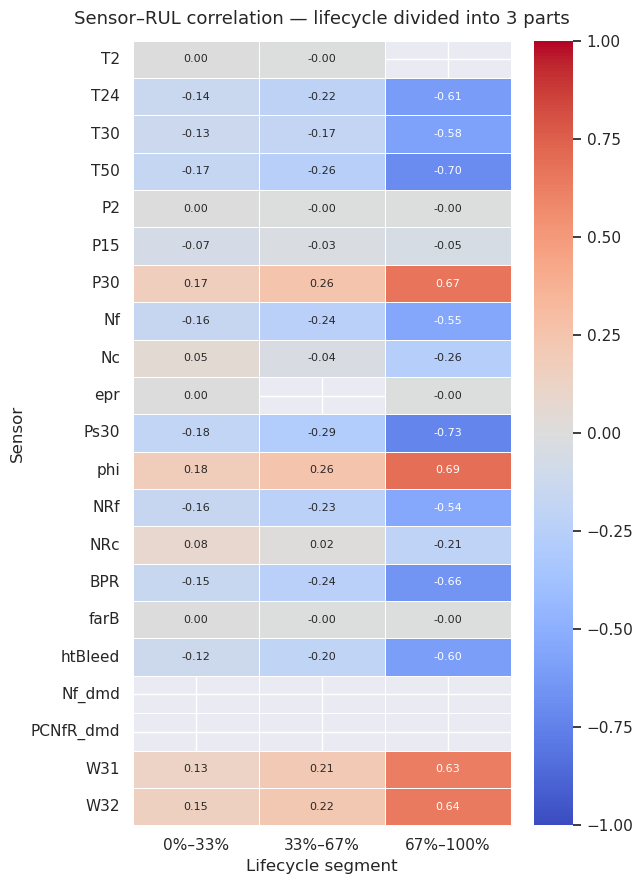

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encounter

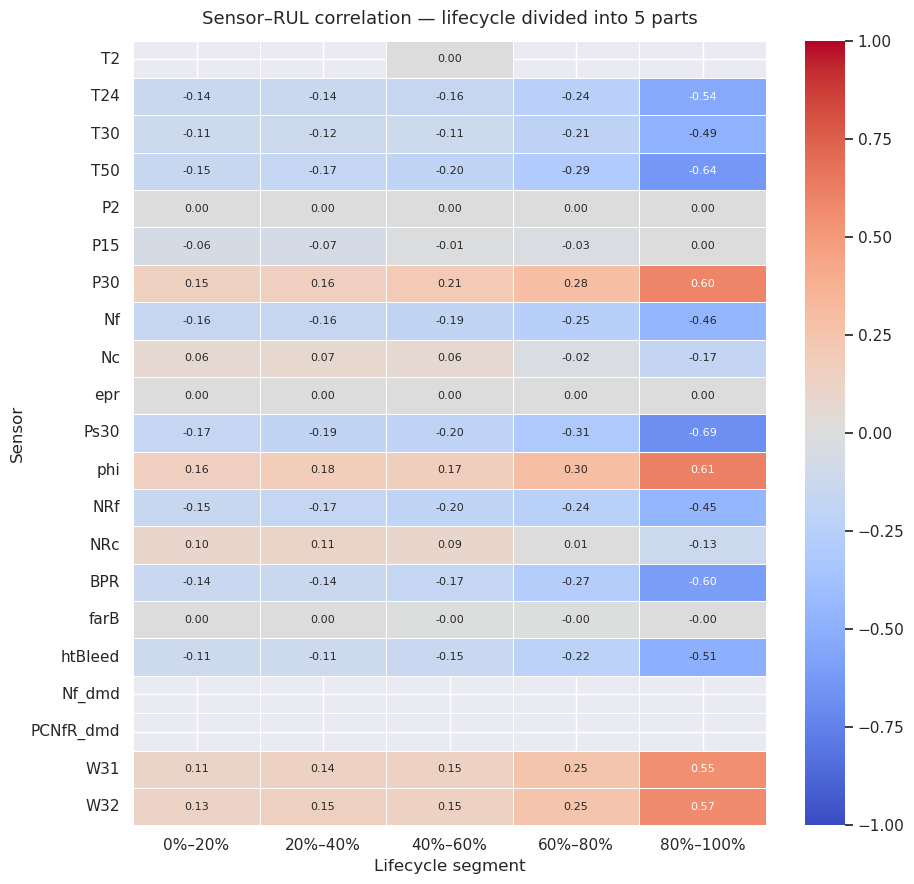

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encounter

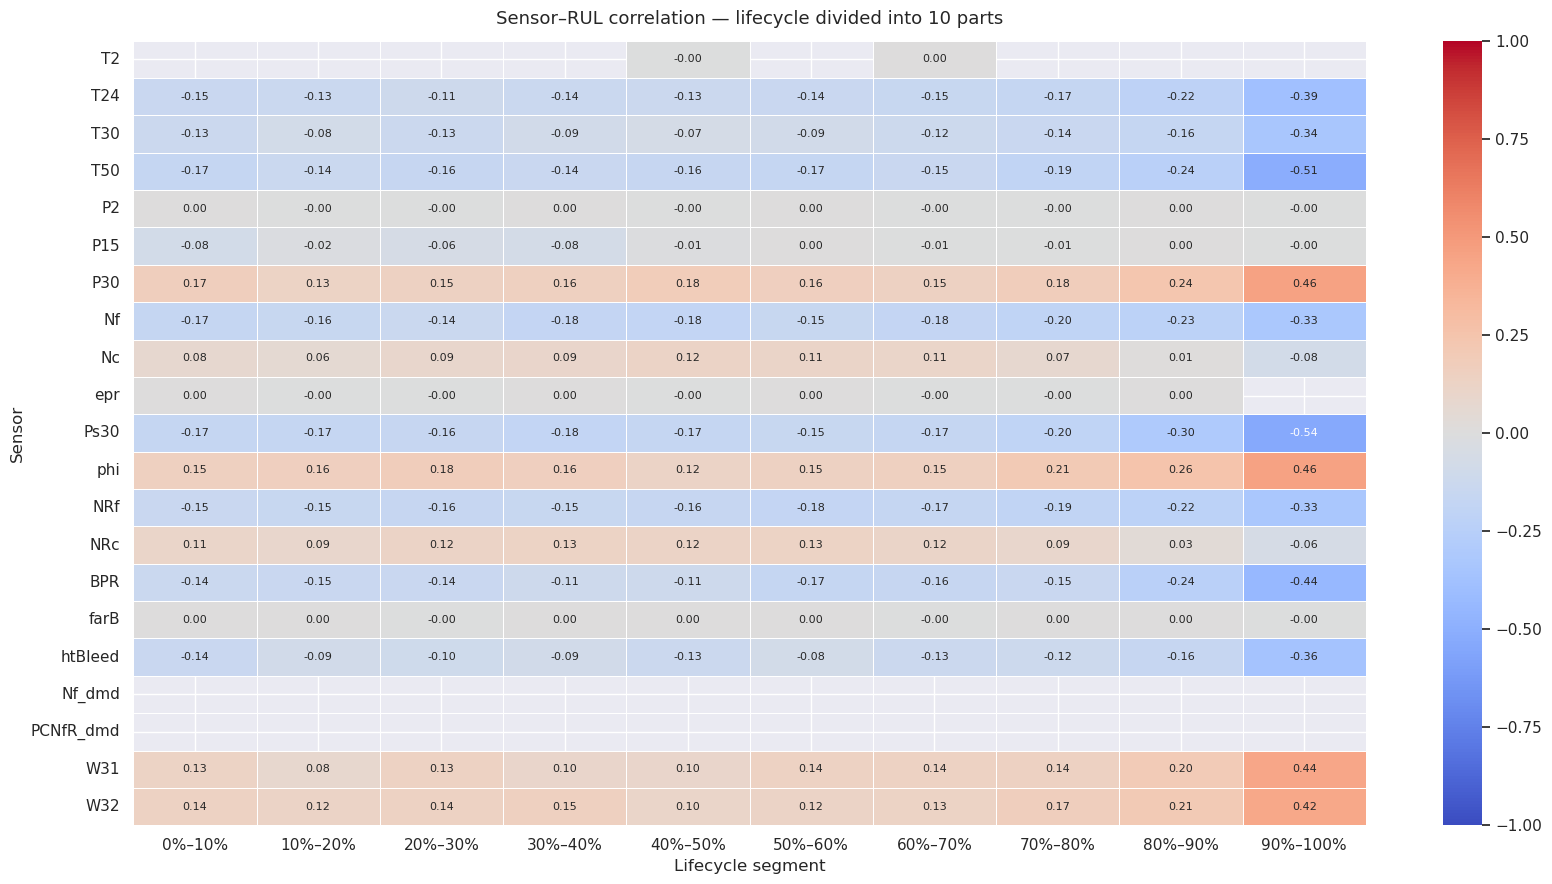

In [4]:
for n_parts in [3, 5, 10]:
    bins = np.linspace(0, 1, n_parts + 1)
    labels = [f'{bins[i]:.0%}–{bins[i+1]:.0%}' for i in range(n_parts)]

    df['segment'] = pd.cut(df['life_pct'], bins=bins, labels=labels, include_lowest=True)

    corr_matrix = (
        df.groupby('segment', observed=True)
          .apply(lambda g: g[SENSORS].corrwith(g['RUL']))
          .T
    )

    fig, ax = plt.subplots(figsize=(n_parts * 1.5 + 2, 9))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'Sensor–RUL correlation — lifecycle divided into {n_parts} parts',
                 fontsize=13, pad=12)
    ax.set_xlabel('Lifecycle segment')
    ax.set_ylabel('Sensor')
    plt.tight_layout()
    plt.show()

## Full sensor correlation heatmaps — 3 lifecycle segments

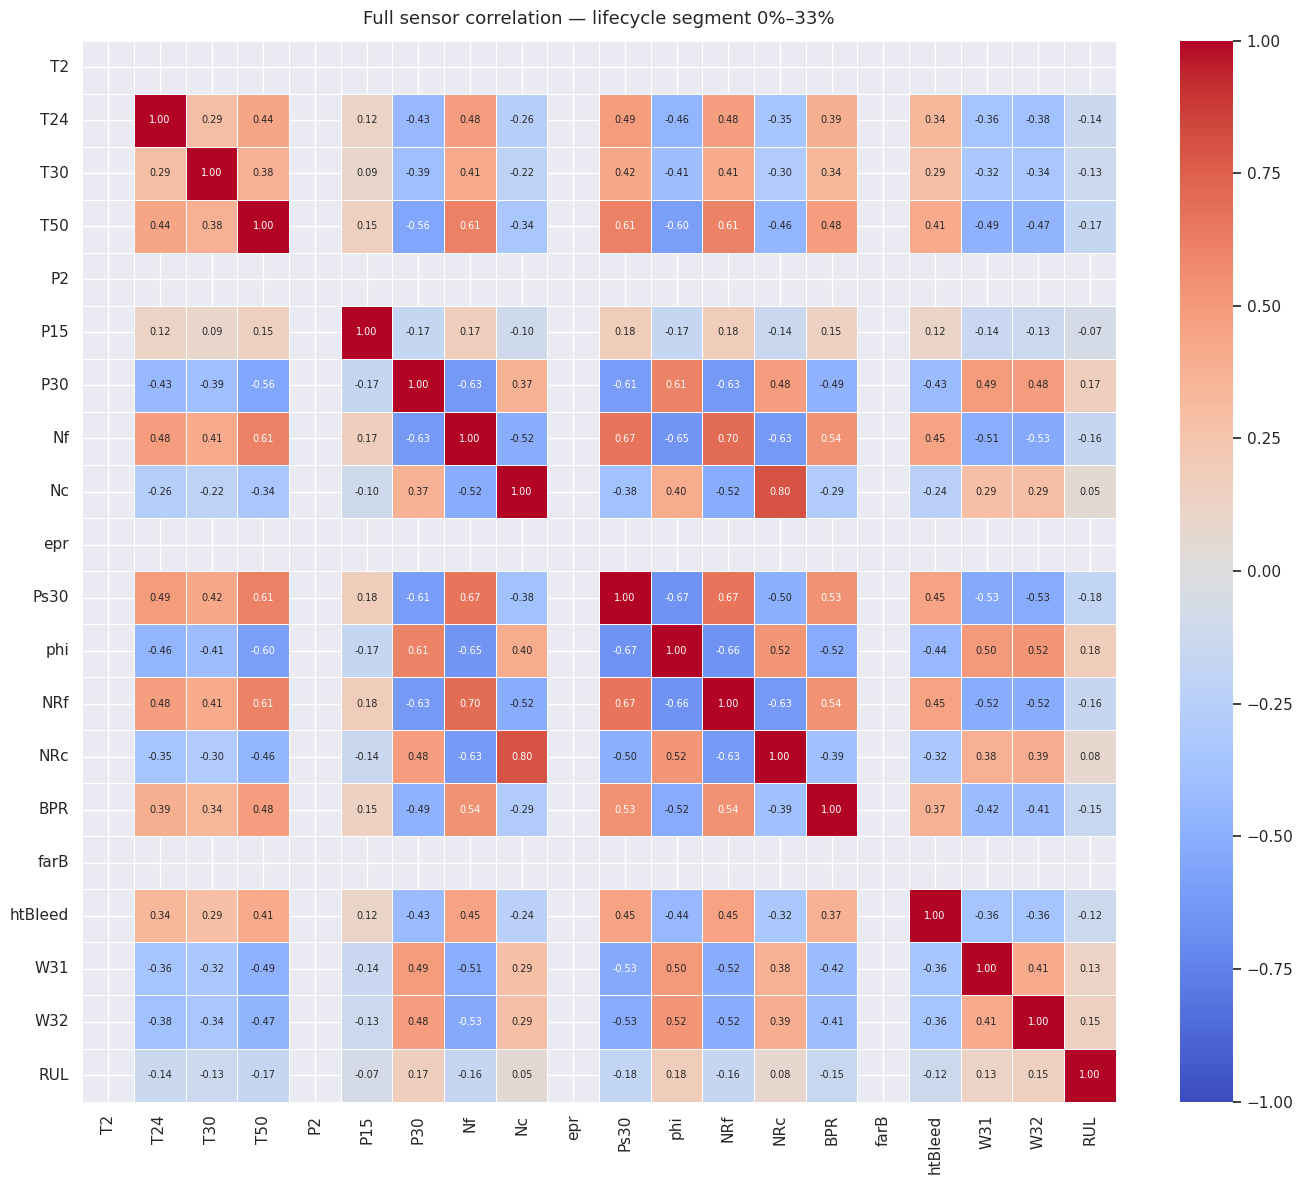

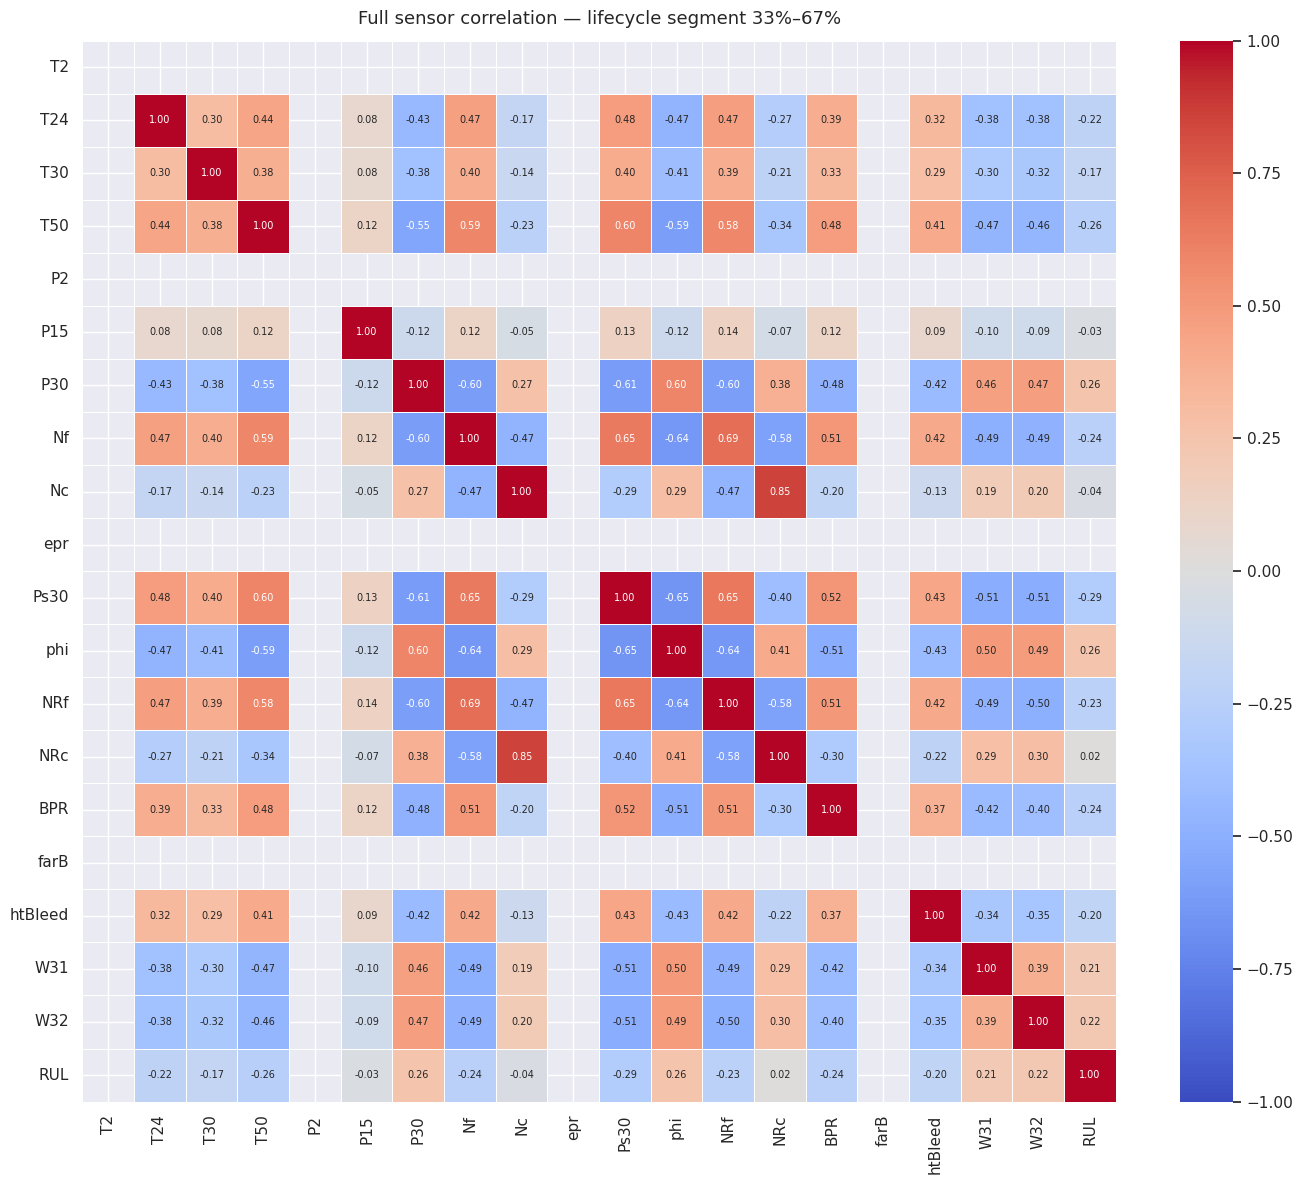

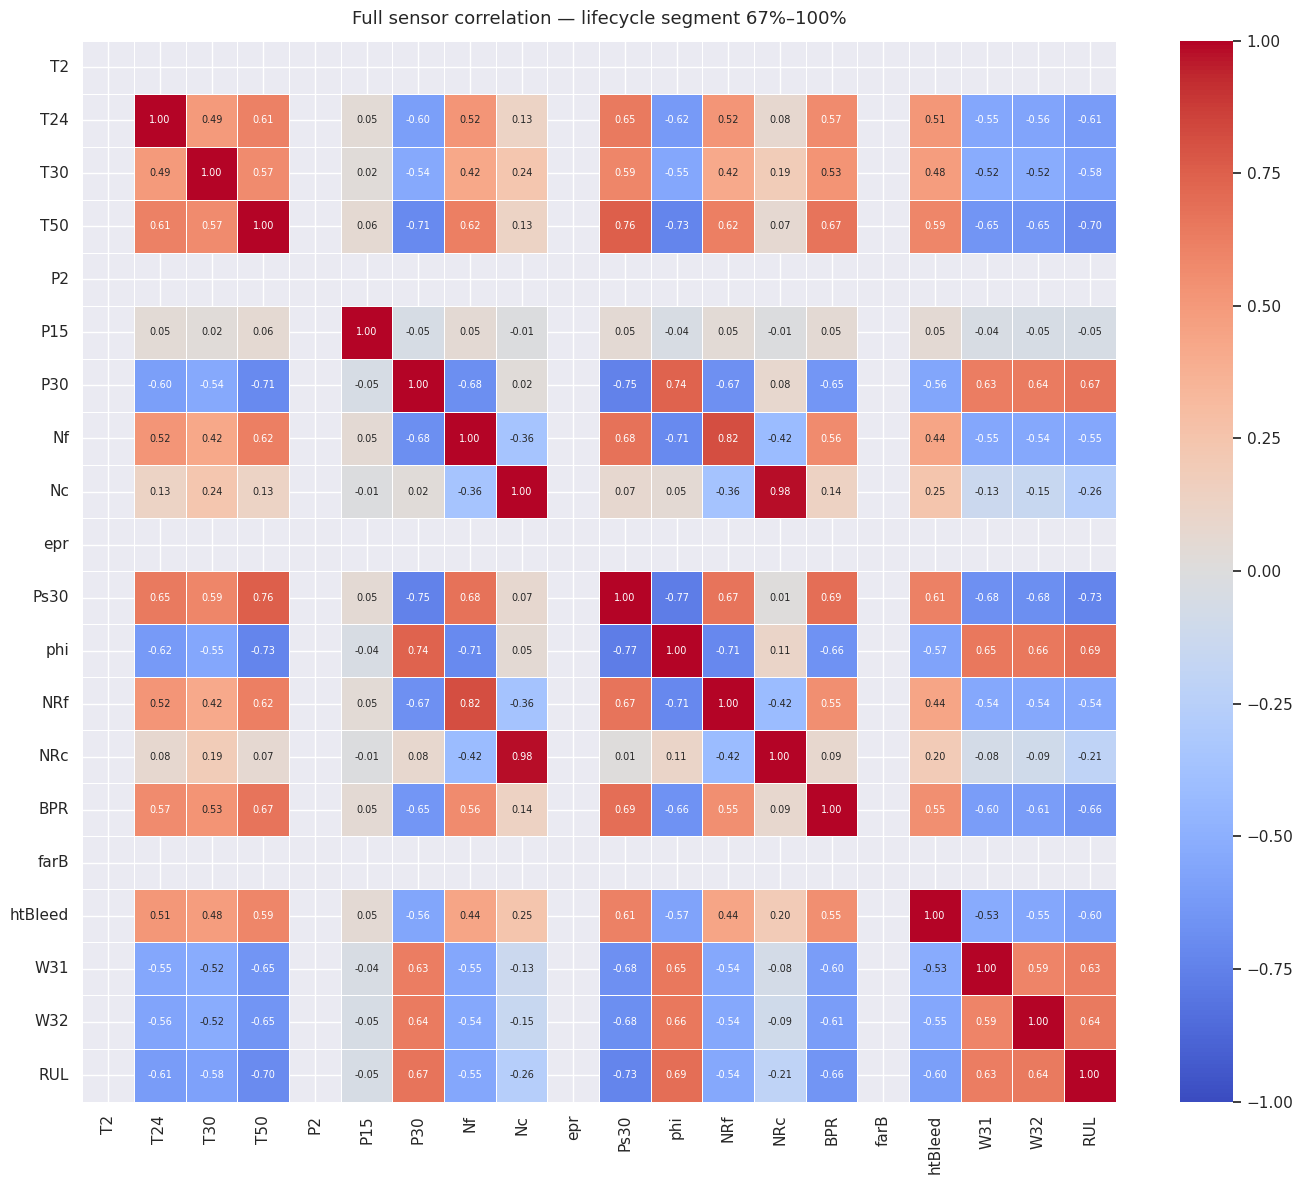

In [5]:
bins = np.linspace(0, 1, 4)
labels = [f'{bins[i]:.0%}–{bins[i+1]:.0%}' for i in range(3)]
df['segment'] = pd.cut(df['life_pct'], bins=bins, labels=labels, include_lowest=True)

for segment in labels:
    subset = df[df['segment'] == segment][SENSORS + ['RUL']]
    subset = subset.loc[:, subset.std() > 0]
    corr = subset.corr()

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title(f'Full sensor correlation — lifecycle segment {segment}', fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()